# Experiment Control

Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.ndimage import gaussian_filter
import matplotlib 
matplotlib.rc('font', family='serif')
matplotlib.rc('font', serif='STIXGeneral')
from cmcrameri import cm  #cmap=cm.lipari 

from optical_setup import OpticalSetup
from CAM.vimbPy.controller import VimbaXController
from time import sleep
opt_setup = OpticalSetup()


## DMD

Initialise

In [2]:
opt_setup._dmd_on()

matrix_height = int(opt_setup.dmd.h)
matrix_width = int(opt_setup.dmd.w)

2026-06-03 13:10:51,581 - ALP41 - SN16017 - INFO - Device connected. SN: 16017, ID: 302
2026-06-03 13:10:51,591 - ALP41 - SN16017 - INFO - Memory allocated successfully. SeqID: 1
2026-06-03 13:10:51,593 - ALP41 - SN16017 - INFO - Memory allocated successfully. SeqID: 2
2026-06-03 13:10:51,594 - ALP41 - SN16017 - INFO - Memory allocated successfully. SeqID: 3
2026-06-03 13:10:51,596 - ALP41 - SN16017 - INFO - Memory allocated successfully. SeqID: 4
2026-06-03 13:10:51,596 - ALP41 - SN16017 - INFO - Memory allocated successfully. SeqID: 5


### Objects

Two Filled Dots

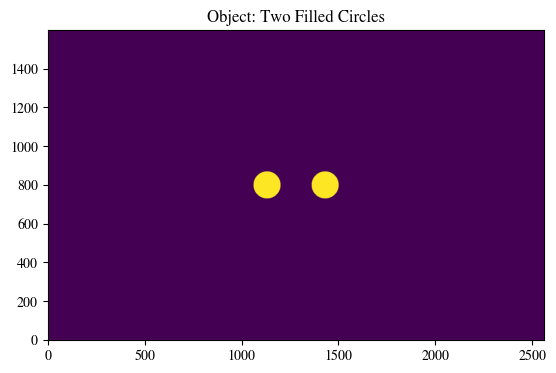

In [3]:
# Object matrix
two_dots = np.zeros((matrix_height, matrix_width))

centre_x = matrix_width // 2
centre_y = matrix_height // 2
seperation = 300

# Circle settings
radius = 70

# Circle centres
x1 = centre_x - seperation // 2
x2 = centre_x + seperation // 2
y1 = y2 = centre_y

# Coordinate grids
Y, X = np.ogrid[:matrix_height, :matrix_width]

# Create filled circles
mask1 = (X - x1)**2 + (Y - y1)**2 <= radius**2
mask2 = (X - x2)**2 + (Y - y2)**2 <= radius**2

# Set circle pixels
two_dots[mask1] = 255
two_dots[mask2] = 255

# Convert to uint8
two_dots = two_dots.astype(np.uint8)

# Display
plt.imshow(two_dots, origin='lower')
plt.title("Object: Two Filled Circles")
plt.show()

Three Filled Dots

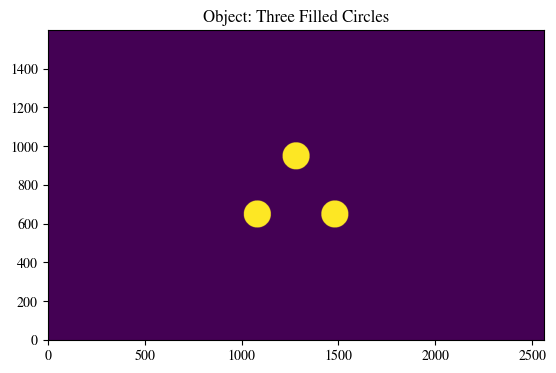

In [4]:

# Object matrix
three_dots = np.zeros((matrix_height, matrix_width))

centre_x = matrix_width // 2
centre_y = matrix_height // 2
separation = 300

# Circle settings
radius = 70

# Circle centres
x1 = centre_x - separation//1.5
x2 = centre_x + separation//1.5
x3 = centre_x
y1 = y2 = centre_y - separation//2
y3 = centre_y + separation//2

# Coordinate grids
Y, X = np.ogrid[:matrix_height, :matrix_width]

# Create filled circles
mask1 = (X - x1)**2 + (Y - y1)**2 <= radius**2
mask2 = (X - x2)**2 + (Y - y2)**2 <= radius**2
mask3 = (X - x3)**2 + (Y - y3)**2 <= radius**2

# Set circle pixels
three_dots[mask1] = 255
three_dots[mask2] = 255
three_dots[mask3] = 255

# Convert to uint8
three_dots = three_dots.astype(np.uint8)

# Display
plt.imshow(three_dots, origin='lower')
plt.title("Object: Three Filled Circles")
plt.show()

Four Filled Dots

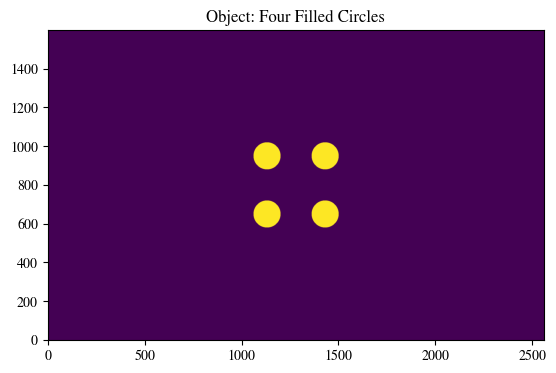

In [5]:
# Object matrix
four_dots = np.zeros((matrix_height, matrix_width))

centre_x = matrix_width // 2
centre_y = matrix_height // 2
separation = 300

# Circle settings
radius = 70

# Circle centres
x1 = centre_x - separation
x2 = centre_x + separation
x3 = centre_x
x4 = centre_x
y1 = y2 = y3 = centre_y

x1 = x2 = centre_x + separation//2
y2 = y3 = centre_y - separation//2
x3 = x4 = centre_x - separation//2
y4 = y1 = centre_y + separation//2

# Coordinate grids
Y, X = np.ogrid[:matrix_height, :matrix_width]

# Create filled circles
mask1 = (X - x1)**2 + (Y - y1)**2 <= radius**2
mask2 = (X - x2)**2 + (Y - y2)**2 <= radius**2
mask3 = (X - x3)**2 + (Y - y3)**2 <= radius**2
mask4 = (X - x4)**2 + (Y - y4)**2 <= radius**2

# Set circle pixels
four_dots[mask1] = 255
four_dots[mask2] = 255
four_dots[mask3] = 255
four_dots[mask4] = 255

# Convert to uint8
four_dots = four_dots.astype(np.uint8)

# Display
plt.imshow(four_dots, origin='lower')
plt.title("Object: Four Filled Circles")
plt.show()

Ring

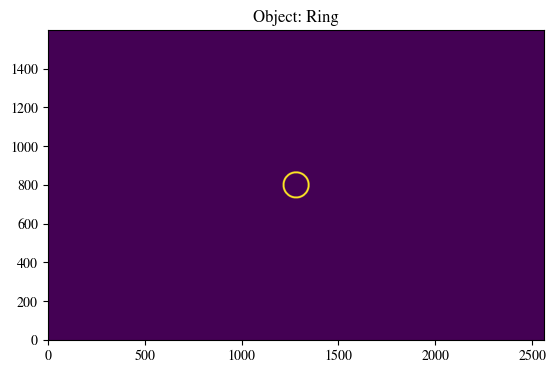

In [6]:
# Object matrix
ring = np.zeros((matrix_height, matrix_width))

centre_x = matrix_width // 2
centre_y = matrix_height // 2

# Circle settings
outer_radius = 70
inner_radius = 60

# Circle centres
x1 = x2 = centre_x
y1 = y2 = centre_y

# Coordinate grids
Y, X = np.ogrid[:matrix_height, :matrix_width]

# Create filled circles
mask1 = (X - x1)**2 + (Y - y1)**2 <= outer_radius**2
mask2 = (X - x2)**2 + (Y - y2)**2 <= inner_radius**2

# Set circle pixels
ring[mask1] = 255
ring[mask2] = 0

# Convert to uint8
ring = ring.astype(np.uint8)

# Display
plt.imshow(ring, origin='lower')
plt.title("Object: Ring")
plt.show()

DMD On

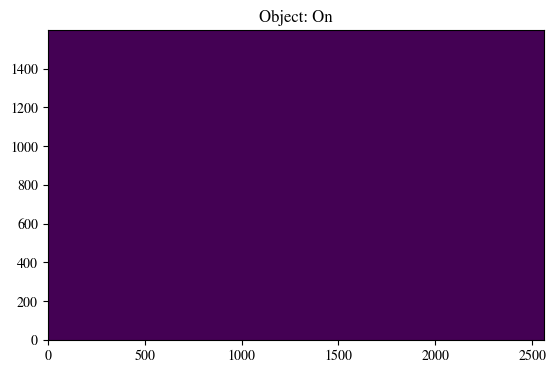

In [7]:
# Object matrix
On = np.ones((matrix_height, matrix_width))*255
#On[:1000, :1000] = 255




# Convert to uint8
On = On.astype(np.uint8)

# Display
plt.imshow(On, origin='lower')
plt.title("Object: On")
plt.show()

### Send To DMD

In [53]:
patterns_dict = {"two dots": two_dots, "three dots": three_dots, "four dots": four_dots, "ring": ring, "on": On}
Pattern = patterns_dict["two dots"]  # Change the key to select different patterns

Pattern=Pattern[np.newaxis, np.newaxis, :, :]  # Add batch and channel dimensions
opt_setup._dmd_display(pattern=Pattern , continuous=False)

## Capturing Image 

Background

In [45]:
import csv

with open(r"C:\Users\lj500\OneDrive - University of Exeter\Desktop\Imaging & tracking objects behind a scattering medium\data\background removal & double dot\background_image.csv") as f:
    reader = csv.reader(f)
    background_image = np.array(list(reader), dtype=float)

Take a picture

2026-06-03 14:05:47,235 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Packet size adjusted successfully.
2026-06-03 14:05:47,245 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record started.


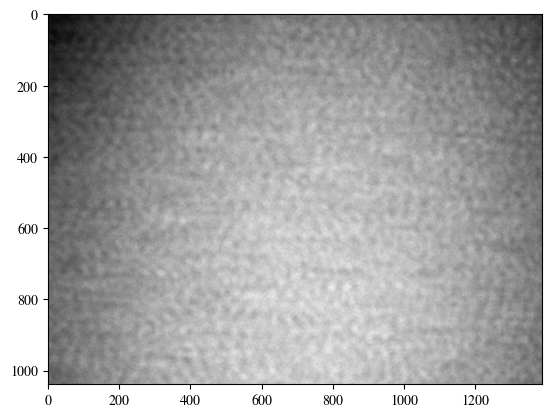

2026-06-03 14:05:48,144 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record stopped.


In [ ]:
opt_setup._cams_off()
opt_setup._cams_on()
opt_setup.trigger_camera()

frame = opt_setup.q_single.get()

img = frame[1] 

plt.imshow(img.squeeze()-background_image, cmap='gray')
#plt.imshow(img.squeeze(), cmap='gray')
plt.show()

custom_name = "C:\\Users\\lj500\\OneDrive - University of Exeter\\Desktop\\Imaging & tracking objects behind a scattering medium\\data\\background removal & double dot\\double dot background removed 13000 micro secs 005.png"
#custom_name = "C:\\Users\\lj500\\OneDrive - University of Exeter\\Desktop\\Imaging & tracking objects behind a scattering medium\\data\\background removal & double dot\\double dot 13000 micro secs 003.png"

plt.imsave(custom_name, img.squeeze(), cmap="gray")

opt_setup._cams_off()

In [ ]:
opt_setup._dmd_off()

## Calculating Background

In [13]:
opt_setup._cams_off()

In [14]:
background = []

In [26]:
for i in range(10):
    print("image "+str(i)+" start")
    opt_setup._cams_on()
    opt_setup.trigger_camera()
    frame = opt_setup.q_single.get()
    img = frame[1].squeeze()
    background.append(img)
    opt_setup._cams_off()
    print("image "+str(i)+" end")
    if i < 9:
        sleep(20)

image 0 start


2026-06-03 13:29:52,005 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Packet size adjusted successfully.
2026-06-03 13:29:52,010 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record started.
2026-06-03 13:29:52,091 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record stopped.


image 0 end
image 1 start


2026-06-03 13:30:15,479 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Packet size adjusted successfully.
2026-06-03 13:30:15,481 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record started.
2026-06-03 13:30:15,595 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record stopped.


image 1 end
image 2 start


...

image 7 end
image 8 start


2026-06-03 13:33:00,540 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Packet size adjusted successfully.
2026-06-03 13:33:00,542 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record started.
2026-06-03 13:33:00,649 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record stopped.


image 8 end
image 9 start


2026-06-03 13:33:23,986 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Packet size adjusted successfully.
2026-06-03 13:33:23,990 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record started.
2026-06-03 13:33:24,086 - vimbPy_DEV_000F314CD29C - INFO - Cam DEV_000F314CD29C - Record stopped.


image 9 end


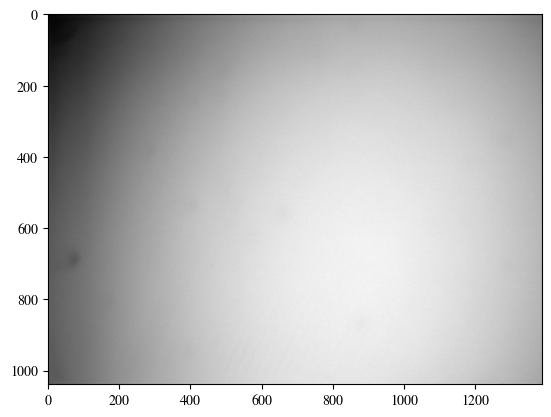

In [27]:

avg_image = np.mean(background, axis=0)
plt.imshow(avg_image.squeeze(), cmap='gray')
plt.show()



In [41]:
print(avg_image)
np.savetxt('C:\\Users\\lj500\\OneDrive - University of Exeter\\Desktop\\Imaging & tracking objects behind a scattering medium\\data\\background removal & double dot\\background_image.csv', avg_image, delimiter=",", fmt='%s')

[[25.25 24.9  25.1  ... 36.75 36.85 37.05]
 [24.75 25.25 25.1  ... 37.1  37.3  37.05]
 [24.75 25.1  24.65 ... 37.15 37.6  37.05]
 ...
 [34.2  34.55 34.25 ... 43.85 44.3  43.7 ]
 [33.6  34.95 34.35 ... 44.05 43.15 43.4 ]
 [34.05 34.   34.1  ... 43.35 43.55 43.6 ]]
